In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm
import random
import seaborn as sns
from typing import Tuple
import pandas as pd

In [2]:
df_users = pd.read_csv('KION_DATASET/data_original/users.csv')
df_interactions = pd.read_csv('KION_DATASET/interactions.csv')
df_items = pd.read_csv('KION_DATASET/data_original/items.csv')

<h2> Предобработка данных

In [3]:
df_interactions.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250.0,72.0
1,699317,1659,2021-05-29,8317.0,100.0
2,656683,7107,2021-05-09,10.0,0.0
3,864613,7638,2021-07-05,14483.0,100.0
4,964868,9506,2021-04-30,6725.0,100.0


In [4]:
df_users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [5]:
df_items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [6]:
df_interactions['last_watch_dt'].unique()
df_interactions['last_watch_dt'] = pd.to_datetime(df_interactions['last_watch_dt'], errors='coerce')
df_interactions = df_interactions.dropna(subset=['last_watch_dt'])

In [ ]:
from datetime import datetime, timedelta
test_size_days = 10

# Тестовый промежуток времени равен 10 дней
max_date = df_interactions['last_watch_dt'].max()
test_start = max_date - timedelta(days=test_size_days)

df_interactions = df_interactions[(df_interactions['watched_pct']>50.0)] # уберем фильмы с просмотром менее 50%
df_interactions_train = df_interactions[df_interactions['last_watch_dt'] < test_start]
df_interactions_test = df_interactions[df_interactions['last_watch_dt'] >= test_start]


In [10]:
train_sorted = df_interactions_train.sort_values(['user_id', 'last_watch_dt'])
    
train = train_sorted.groupby('user_id').tail(15) # у пользователей в train берем последние 15 фильмов

In [12]:
def get_active_users_ids(df, min_interactions=2):
    """Возвращает ID пользователей, у которых больше минимального числа взаимодействий."""
    counts = df['user_id'].value_counts()
    return set(counts[counts >= min_interactions].index)

# 1. Находим активных пользователей в каждом наборе данных
active_train_ids = get_active_users_ids(train)
active_test_ids = get_active_users_ids(df_interactions_test)

# 2. Находим пересечение (пользователи, активные и в train, и в test)
common_active_users = active_train_ids & active_test_ids

# 3. Фильтруем исходные данные, оставляя только общих активных пользователей
df_interactions_train = train[train['user_id'].isin(common_active_users)]
df_interactions_test = df_interactions_test[df_interactions_test['user_id'].isin(common_active_users)]

In [15]:
def precision(recommended_list, bought_list):
    recommended = np.array(recommended_list)
    bought = np.array(bought_list)

    # флаги: какие рекомендованные товары действительно куплены
    flags = np.isin(recommended, bought)

    return flags.sum() / len(recommended)


def precision_at_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    flags = np.isin(recommended, bought)

    return flags.sum() / k


def money_precision_at_k(recommended_list, bought_list, prices_recommended, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    prices = np.array(prices_recommended[:k])

    # флаги: куплен ли товар
    flags = np.isin(recommended, bought)

    # учитываем деньги
    return np.dot(flags, prices) / prices.sum()

In [16]:
def recall(recommended_list, bought_list):
    recommended = np.array(recommended_list)
    bought = np.array(bought_list)

    # какие купленные товары были среди рекомендованных
    flags = np.isin(bought, recommended)

    return flags.sum() / len(bought)


def recall_at_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    flags = np.isin(bought, recommended)

    return flags.sum() / len(bought)


def money_recall_at_k(recommended_list, bought_list, prices_recommended, prices_bought, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    prices_bought = np.array(prices_bought)

    # флаги: купленный товар есть в топ-k рекомендациях
    flags = np.isin(bought, recommended)

    # учитываем деньги (важны цены купленных товаров)
    return np.dot(flags, prices_bought) / prices_bought.sum()

In [17]:
def ap_k(recommended_list, bought_list, k=5):
    if not recommended_list or not len(bought_list):
        return 0.0
    
    # Ограничиваем список рекомендаций сверху значением k
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    
    # Флаги: попал ли рекомендованный товар в список покупок
    flags = np.isin(recommended, bought)
    
    # Если нет попаданий — AP = 0
    if not np.any(flags):
        return 0.0
    
    sum_precision = 0.0
    hits = 0
    
    # Итерируем только по фактической длине рекомендаций (но не более k)
    for i, is_hit in enumerate(flags):
        if is_hit:
            hits += 1
            precision_at_i = hits / (i + 1)  # Precision@i+1
            sum_precision += precision_at_i
    
    # Нормализуем на минимальное из (k, число релевантных)
    normalization = min(k, len(bought))
    return sum_precision / normalization if normalization > 0 else 0.0


def map_k(recommended_list, bought_list, k=5, u=1):
    
    # your_code
    if u == 1:
        return ap_k(recommended_list[u-1], bought_list[u-1], k=5)
    
    sum = 0
    for i in range(0, u):
        ap_k_map = ap_k(recommended_list[i], bought_list[i], k=5)
        sum += ap_k_map

    result = sum / u
    
    return result

In [18]:
data_test_group = df_interactions_test.groupby(df_interactions_test['user_id'])['item_id'].unique().reset_index()
data_test_group.columns = ['user_id', 'item_id']
data_test_group

,user_id,item_id
0,259,"[10509, 10772]"
1,655,"[11188, 5199]"
2,753,"[9327, 8350]"
3,835,"[5434, 11640, 10878]"
4,960,"[8636, 12770, 6809]"
...,...,...
5014,1096841,"[10219, 3620]"
5015,1097296,"[3006, 16087]"
5016,1097444,"[13650, 12841, 13099, 1124, 12250, 2483]"
5017,1097459,"[11844, 7793]"


In [19]:
userids = data_test_group['user_id'].values
 
userids_test = np.arange(len(userids))

<h2>UserKNN

In [30]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

class UserKNN:
    def __init__(self, k=5, min_similarity=0.1):
        self.k = k
        self.min_similarity = min_similarity
        
        # Маппинги ID -> Индекс для быстрого доступа O(1)
        self.user_id_to_idx = {}
        self.idx_to_user_id = {}
        self.item_id_to_idx = {}
        self.idx_to_item_id = {}
        
        self.user_item_matrix = None  # Разреженная матрица (CSR)
        self.user_similarity = None   # Матрица схожести (Плотная, память ограничивает)
        self.n_users = 0
        self.n_items = 0

    def fit(self, interactions):
        """Обучение модели: построение матриц и расчет схожести."""
        self._build_mappings(interactions)
        self._build_matrix(interactions)
        self._compute_similarity()
        return self

    def _build_mappings(self, interactions):
        """Создает словари для быстрого перевода ID в индексы и обратно."""
        unique_users = interactions['user_id'].unique()
        unique_items = interactions['item_id'].unique()
        
        self.user_id_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
        self.idx_to_user_id = {idx: uid for uid, idx in self.user_id_to_idx.items()}
        
        self.item_id_to_idx = {iid: idx for idx, iid in enumerate(unique_items)}
        self.idx_to_item_id = {idx: iid for iid, idx in self.item_id_to_idx.items()}
        
        self.n_users = len(unique_users)
        self.n_items = len(unique_items)

    def _build_matrix(self, interactions):
        """Создает разреженную матрицу пользователь-товар."""
        user_codes = interactions['user_id'].map(self.user_id_to_idx)
        item_codes = interactions['item_id'].map(self.item_id_to_idx)
        
        # Удаляем строки, где маппинг не удался (если есть новые ID, хотя в fit их не должно быть)
        mask = user_codes.notna() & item_codes.notna()
        
        self.user_item_matrix = csr_matrix(
            (interactions.loc[mask, 'watched_pct'], 
             (user_codes.loc[mask], item_codes.loc[mask])),
            shape=(self.n_users, self.n_items)
        )

    def _compute_similarity(self):
        """Вычисляет матрицу косинусной схожести между пользователями."""
        # Внимание: результат плотный (N_users x N_users). 
        # Для >50k пользователей лучше использовать Approximate NN (например, FAISS/Annoy).
        self.user_similarity = cosine_similarity(self.user_item_matrix, dense_output=True)
        np.fill_diagonal(self.user_similarity, 0)

    def _get_user_idx(self, user_id):
        return self.user_id_to_idx.get(user_id)

    def _get_item_idx(self, item_id):
        return self.item_id_to_idx.get(item_id)

    def _get_similar_users(self, user_idx):
        """Возвращает индексы и веса похожих пользователей для данного индекса."""
        similarities = self.user_similarity[user_idx]
        
        # Берем топ-k + фильтр по порогу
        # argsort быстрее, чем поиск по условию + сортировка
        top_indices = np.argsort(similarities)[::-1][:self.k]
        
        similar_users = []
        for idx in top_indices:
            sim = similarities[idx]
            if sim >= self.min_similarity:
                similar_users.append((idx, sim))
            else:
                break # Так как отсортировано по убыванию, дальше смысла нет
        return similar_users

    def predict(self, user_id, item_id):
        """Предсказывает рейтинг для конкретной пары пользователь-товар."""
        user_idx = self._get_user_idx(user_id)
        item_idx = self._get_item_idx(item_id)
        
        if user_idx is None or item_idx is None:
            return 0.0

        similar_users = self._get_similar_users(user_idx)
        if not similar_users:
            return 0.0

        # Векторизованный сбор рейтингов соседей
        neighbor_indices = [idx for idx, _ in similar_users]
        neighbor_weights = np.array([w for _, w in similar_users])
        
        # Получаем рейтинги соседей на этот товар из разреженной матрицы
        # .toarray() здесь безопасно, так как берем один столбец (или срез)
        neighbor_ratings = self.user_item_matrix[neighbor_indices, item_idx].toarray().flatten()
        
        # Фильтруем соседей, которые не оценили этот товар
        mask = neighbor_ratings > 0
        if not np.any(mask):
            return 0.0
            
        weights = neighbor_weights[mask]
        ratings = neighbor_ratings[mask]
        
        if np.sum(weights) > 0:
            return float(np.average(ratings, weights=weights))
        else:
            return float(np.mean(ratings))

    def recommend(self, user_id, n_recommendations=10):
        """Генерирует топ-N рекомендаций для пользователя (Векторизовано)."""
        user_idx = self._get_user_idx(user_id)
        if user_idx is None:
            return []

        # 1. Находим похожих пользователей ОДИН РАЗ
        similar_users = self._get_similar_users(user_idx)
        if not similar_users:
            return []

        neighbor_indices = [idx for idx, _ in similar_users]
        neighbor_weights = np.array([w for _, w in similar_users])

        # 2. Получаем матрицу рейтингов соседей (K соседей x Все товары)
        # Это быстро, так как матрица разреженная
        neighbors_matrix = self.user_item_matrix[neighbor_indices] 
        
        # 3. Считаем взвешенный скор для ВСЕХ товаров сразу
        # (Weights.T @ Matrix) -> вектор скоров длиной N_items
        scores = neighbor_weights @ neighbors_matrix
        
        # 4. Обнуляем товары, которые пользователь уже видел
        user_rated_items = self.user_item_matrix[user_idx].indices
        scores[user_rated_items] = -np.inf 

        # 5. Находим топ-N индексов
        # argpartition быстрее argsort для получения только топ-N
        if n_recommendations >= len(scores):
            top_indices = np.argsort(scores)[::-1]
        else:
            top_indices = np.argpartition(scores, -n_recommendations)[-n_recommendations:]
            top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]

        # 6. Фильтруем товары с нулевым скором и переводим в ID
        recommendations = []
        for idx in top_indices:
            if scores[idx] > 0:
                recommendations.append(self.idx_to_item_id[idx])
            if len(recommendations) >= n_recommendations:
                break
                
        return recommendations

In [31]:
model_UserKNN = UserKNN(k=5, min_similarity=0.07)
model_UserKNN.fit(df_interactions_train)


In [32]:
data_test_group = df_interactions_test.groupby('user_id')['item_id'].unique().reset_index()
data_test_group.columns = ['user_id', 'item_id']
data_test_group

,user_id,item_id
0,259,"[10509, 10772]"
1,655,"[11188, 5199]"
2,753,"[9327, 8350]"
3,835,"[5434, 11640, 10878]"
4,960,"[8636, 12770, 6809]"
...,...,...
5014,1096841,"[10219, 3620]"
5015,1097296,"[3006, 16087]"
5016,1097444,"[13650, 12841, 13099, 1124, 12250, 2483]"
5017,1097459,"[11844, 7793]"


In [33]:
# Получаем уникальных пользователей из тестовой выборки
userids = data_test_group['user_id'].values

# Создаем словари для двунаправленного маппинга
user_id_to_idx = {uid: idx for idx, uid in enumerate(userids)}
idx_to_user_id = {idx: uid for uid, idx in user_id_to_idx.items()}

In [34]:
recos_user = []
for i in range(len(userids_test)):
   recommendations = model_UserKNN.recommend(userids[i], n_recommendations=10)
   recos_user.append({'item_id': recommendations})

result_user_knn = pd.DataFrame(recos_user, userids).reset_index()
result_user_knn.to_csv('user_knn_recommendations.csv', index=False, encoding='utf-8')

result_user_knn


,index,item_id
0,259,"[3223, 15947, 13865, 9728, 15521, 9062, 12452,..."
1,655,"[734, 3558, 4151, 16434, 14167, 15297]"
2,753,"[12995, 11987, 3734, 2858, 884, 14998, 4475, 7..."
3,835,"[8254, 11348, 3734, 9696]"
4,960,"[2823, 4495, 3773, 5315, 3384]"
...,...,...
5014,1096841,"[6162, 10878, 12252, 7626, 13865, 211]"
5015,1097296,"[14683, 2720, 4457, 14317, 13865]"
5016,1097444,"[5964, 11469, 281, 4702, 1106, 8419, 9617, 141..."
5017,1097459,"[3153, 6455, 4754, 10440, 9728, 9817]"


In [35]:
# import time
# import pandas as pd
# from tqdm import tqdm

# n_recommendations = 10
# userids = data_test_group['user_id'].values

# recos_user = []
# start_time = time.time()

# # tqdm оборачивает итератор и показывает прогресс-бар
# for i in tqdm(range(len(userids)), desc="Генерация рекомендаций"):
#     try:
#         user_id = userids[i]
#         recommendations = model_UserKNN.recommend(user_id, n_recommendations=n_recommendations)
        
#         recos_user.append({
#             'user_id': user_id,
#             'item_id': recommendations,
#             'n_recommended': len(recommendations)  # Полезно для отладки
#         })
#     except Exception as e:
#         # Логгируем ошибку, но не останавливаем весь процесс
#         recos_user.append({
#             'user_id': userids[i],
#             'item_id': [],
#             'error': str(e)
#         })

# elapsed_time = time.time() - start_time

# # Создаем финальный DataFrame
# result_user_knn = pd.DataFrame(recos_user)

# print(f"✅ Готово! Обработано {len(result_user_knn)} пользователей за {elapsed_time:.2f} сек.")
# print(f"⚡ Средняя скорость: {len(result_user_knn) / elapsed_time:.1f} пользователей/сек")

In [36]:
print('UserKNN_map_k =', map_k(result_user_knn['item_id'], data_test_group['item_id'], k=10, u=len(data_test_group)))

UserKNN_map_k = 0.007444101303933947


<h2>ItemKNN

In [37]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

class ItemKNN:
    def __init__(self, k=10, min_similarity=0.1):
        self.k = k
        self.min_similarity = min_similarity
        
        # Словари для быстрого маппинга ID <-> Индекс (O(1))
        self.user_id_to_idx = {}
        self.idx_to_user_id = {}
        self.item_id_to_idx = {}
        self.idx_to_item_id = {}
        
        self.user_item_matrix = None  # Разреженная матрица (CSR): Users x Items
        self.item_similarity = None   # Матрица схожести товаров: Items x Items
        self.n_users = 0
        self.n_items = 0

    def fit(self, interactions):
        """Обучение модели: построение матриц и расчет схожести товаров."""
        self._build_mappings(interactions)
        self._build_matrix(interactions)
        self._compute_similarity()
        return self

    def _build_mappings(self, interactions):
        """Создает словари для быстрого перевода ID в индексы."""
        unique_users = interactions['user_id'].unique()
        unique_items = interactions['item_id'].unique()
        
        self.user_id_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
        self.idx_to_user_id = {idx: uid for uid, idx in self.user_id_to_idx.items()}
        
        self.item_id_to_idx = {iid: idx for idx, iid in enumerate(unique_items)}
        self.idx_to_item_id = {idx: iid for iid, idx in self.item_id_to_idx.items()}
        
        self.n_users = len(unique_users)
        self.n_items = len(unique_items)

    def _build_matrix(self, interactions):
        """Создает разреженную матрицу пользователь-товар."""
        # Используем map вместо повторного создания Categorical
        user_codes = interactions['user_id'].map(self.user_id_to_idx)
        item_codes = interactions['item_id'].map(self.item_id_to_idx)
        
        # Фильтруем строки с NaN (если вдруг есть новые ID)
        mask = user_codes.notna() & item_codes.notna()
        
        self.user_item_matrix = csr_matrix(
            (interactions.loc[mask, 'watched_pct'], 
             (user_codes.loc[mask], item_codes.loc[mask])),
            shape=(self.n_users, self.n_items)
        )

    def _compute_similarity(self):
        """Вычисляет матрицу косинусной схожести между ТОВАРАМИ."""
        # Транспонируем: (Items x Users) для расчета схожести колонок
        # cosine_similarity работает эффективно с разреженными матрицами на входе
        self.item_similarity = cosine_similarity(
            self.user_item_matrix.T, 
            dense_output=True  # Результат все равно будет плотным (Items x Items)
        )
        np.fill_diagonal(self.item_similarity, 0)  # Товар не похож сам на себя

    def _get_user_idx(self, user_id):
        return self.user_id_to_idx.get(user_id)

    def _get_item_idx(self, item_id):
        return self.item_id_to_idx.get(item_id)

    def _get_similar_items(self, item_idx):
        """Возвращает индексы и веса похожих товаров для данного индекса."""
        similarities = self.item_similarity[item_idx]
        
        # Берем топ-k + фильтр по порогу
        # Используем argsort для сортировки по убыванию
        top_indices = np.argsort(similarities)[::-1][:self.k]
        
        similar_items = []
        for idx in top_indices:
            sim = similarities[idx]
            if sim >= self.min_similarity:
                similar_items.append((idx, sim))
            else:
                break  # Отсортировано по убыванию, дальше нет смысла
        return similar_items

    def predict(self, user_id, item_id):
        """Предсказывает рейтинг для пары пользователь-товар."""
        user_idx = self._get_user_idx(user_id)
        target_item_idx = self._get_item_idx(item_id)
        
        if user_idx is None or target_item_idx is None:
            return 0.0

        similar_items = self._get_similar_items(target_item_idx)
        if not similar_items:
            return 0.0

        # Векторизованный сбор рейтингов пользователя для похожих товаров
        neighbor_indices = [idx for idx, _ in similar_items]
        neighbor_weights = np.array([w for _, w in similar_items])
        
        # Получаем рейтинг пользователя для этих товаров из разреженной матрицы
        # Берем срез строки пользователя по нужным колонкам (товарам)
        user_ratings_row = self.user_item_matrix[user_idx, neighbor_indices]
        neighbor_ratings = np.asarray(user_ratings_row).flatten()
        
        # Фильтруем товары, которые пользователь еще не смотрел (рейтинг = 0)
        mask = neighbor_ratings > 0
        if not np.any(mask):
            return 0.0
            
        weights = neighbor_weights[mask]
        ratings = neighbor_ratings[mask]
        
        if np.sum(weights) > 0:
            return float(np.average(ratings, weights=weights))
        else:
            return float(np.mean(ratings))

    def recommend(self, user_id, n_recommendations=10):
        """Генерирует топ-N рекомендаций (Векторизовано)."""
        user_idx = self._get_user_idx(user_id)
        if user_idx is None:
            return []

        # 1. Получаем товары, которые пользователь уже смотрел
        user_rated_items = self.user_item_matrix[user_idx].indices
        if len(user_rated_items) == 0:
            return []  # Холодный старт: нет истории -> нет рекомендаций

        # 2. Для каждого просмотренного товара находим похожие и агрегируем скоры
        # Создаем массив для накопления скоров всех товаров
        scores = np.zeros(self.n_items)
        
        for rated_item_idx in user_rated_items:
            similar_items = self._get_similar_items(rated_item_idx)
            if not similar_items:
                continue
                
            # Веса схожести для похожих товаров
            for sim_idx, sim_weight in similar_items:
                # Если товар еще не был просмотрен пользователем, добавляем вклад в скор
                if sim_idx not in user_rated_items:
                    # Рейтинг пользователя для просмотренного товара как вес влияния
                    user_rating = self.user_item_matrix[user_idx, rated_item_idx]
                    scores[sim_idx] += sim_weight * user_rating

        # 3. Обнуляем уже просмотренные товары (защита от дубликатов)
        scores[user_rated_items] = -np.inf

        # 4. Находим топ-N индексов с максимальным скором
        # argpartition быстрее, чем полный argsort
        if n_recommendations >= len(scores):
            top_indices = np.argsort(scores)[::-1]
        else:
            top_indices = np.argpartition(scores, -n_recommendations)[-n_recommendations:]
            # Сортируем только отобранный топ для корректного порядка
            top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]

        # 5. Переводим индексы обратно в ID товаров
        recommendations = []
        for idx in top_indices:
            if scores[idx] > 0:  # Берем только товары с положительным скором
                recommendations.append(self.idx_to_item_id[idx])
            if len(recommendations) >= n_recommendations:
                break
                
        return recommendations

In [38]:
model_ItemKNN = ItemKNN(k=9, min_similarity=0.1)
model_ItemKNN.fit(df_interactions_train)

In [39]:
recos_item = []
for i in range(len(userids_test)):
   recommendations = model_ItemKNN.recommend(userids[i], n_recommendations=10)
   recos_item.append({'item_id': recommendations})

result_item_knn = pd.DataFrame(recos_item, userids).reset_index()
result_item_knn

,index,item_id
0,259,"[4034, 3168, 11840, 15521, 12838, 14135, 7412,..."
1,655,"[10645, 1839, 835, 16349, 11298, 16434, 11200,..."
2,753,"[928, 1757, 2257, 7442, 3708, 14591, 14728, 13..."
3,835,"[7005, 5532, 3471, 15191, 14179, 13683, 11291,..."
4,960,"[7442, 16238, 3791, 7485, 5093, 12428, 14733, ..."
...,...,...
5014,1096841,"[11340, 9853, 5061, 11576, 14456, 12829, 12514..."
5015,1097296,"[12278, 7027, 7189, 1351, 6666, 6576, 10506, 1..."
5016,1097444,"[5964, 9199, 1757, 5114, 2590, 254, 10427, 187..."
5017,1097459,"[15861, 7437, 14222, 7755, 14223, 548, 11135, ..."


In [40]:
print('ItemKNN_map_k =', map_k(result_item_knn['item_id'], data_test_group['item_id'], k=10, u=len(data_test_group)))

ItemKNN_map_k = 0.0028397644506431116


<h2>ALS

In [41]:
class ALS:
    def __init__(self, n_factors=10, alpha=40, regularization=0.1, iterations=15):
        """
        Инициализация ALS модели
        
        Parameters:
        - n_factors: количество латентных факторов
        - alpha: параметр уверенности для неявной обратной связи
        - regularization: коэффициент регуляризации (lambda)
        - iterations: количество итераций обучения
        """
        self.n_factors = n_factors
        self.alpha = alpha
        self.regularization = regularization
        self.iterations = iterations
        self.user_factors = None
        self.item_factors = None
        self.loss_history = []
    
    def fit(self, ratings):
        """
        Обучение ALS модели
        
        Parameters:
        - ratings: scipy sparse matrix в формате (users × items)
        """
        n_users, n_items = ratings.shape
        
        # Инициализация матриц факторов
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.item_factors = np.random.normal(0, 0.1, (n_items, self.n_factors))
        
        print("Начинаем обучение ALS...")
        
        for iteration in range(self.iterations):
            # Шаг 1: Фиксируем item factors, обновляем user factors
            for u in range(n_users):
                # Получаем индексы и значения оценок пользователя
                user_ratings = ratings[u].toarray().flatten()
                rated_items = np.where(user_ratings > 0)[0]
                
                if len(rated_items) > 0:
                    # Вычисляем уверенности для неявной обратной связи
                    confidence = 1 + self.alpha * user_ratings[rated_items]
                    
                    # Матрица item factors для оцененных items
                    Y = self.item_factors[rated_items]
                    
                    # Вычисляем матрицу A и вектор b
                    weighted_Y_T = Y.T * confidence  # (n_factors, n_rated_items)
                    A = weighted_Y_T @ Y + self.regularization * np.eye(self.n_factors) # (n_factors, n_factors)
                    b = Y.T @ confidence # (n_factors,)
                    
                    # Решаем линейную систему
                    self.user_factors[u] = np.linalg.solve(A, b)
            
            # Шаг 2: Фиксируем user factors, обновляем item factors
            for i in range(n_items):
                # Получаем индексы и значения оценок для item
                item_ratings = ratings[:, i].toarray().flatten()
                rating_users = np.where(item_ratings > 0)[0]
                
                if len(rating_users) > 0:
                    # Вычисляем уверенности
                    confidence = 1 + self.alpha * item_ratings[rating_users]
                    
                    # Матрица user factors для оценивших пользователей
                    X = self.user_factors[rating_users]
                    
                    # Вычисляем матрицу A и вектор b
                    weighted_X_T = X.T * confidence  # (n_factors, n_rated_users)
                    A = weighted_X_T @ X + self.regularization * np.eye(self.n_factors) # (n_factors, n_factors)
                    b = X.T @ confidence # (n_factors,)
                    
                    # Решаем линейную систему
                    self.item_factors[i] = np.linalg.solve(A, b)
            
            # Вычисляем loss
            loss = self._compute_loss(ratings)
            self.loss_history.append(loss)
            print(f"Итерация {iteration + 1}/{self.iterations}, Loss: {loss:.4f}")
    
    def _compute_loss(self, ratings):
        """Вычисление функции потерь"""
        loss = 0
        n_users, n_items = ratings.shape
        
        for u in range(n_users):
            for i in range(n_items):
                if ratings[u, i] > 0:
                    prediction = self.user_factors[u] @ self.item_factors[i]
                    confidence = 1 + self.alpha * ratings[u, i]
                    error = confidence - prediction
                    loss += error ** 2
        
        # Добавляем регуляризацию
        reg_loss = self.regularization * (
            np.sum(self.user_factors ** 2) + np.sum(self.item_factors ** 2)
        )
        
        return loss + reg_loss
    
    def predict(self, user_id, item_id):
        """Предсказание оценки"""
        return self.user_factors[user_id] @ self.item_factors[item_id]
    
    def recommend(self, user_id, n_recommendations=10):
        """Рекомендации для пользователя"""
        user_vector = self.user_factors[user_id]
        scores = user_vector @ self.item_factors.T
        top_items = np.argsort(scores)[::-1][:n_recommendations]
        return top_items, scores[top_items]
    
    def plot_loss(self):
        """Визуализация истории потерь"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, marker='o')
        plt.title('История обучения ALS')
        plt.xlabel('Итерация')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()

In [42]:
from scipy.sparse import csr_matrix
import pandas as pd
import numpy as np

def create_matrix(train_df, test_df=None, user_col='user_id', item_col='item_id', value_col='watched_pct'):
    """
    Создает матрицы взаимодействий.
    ВАЖНО: Маппинги строятся только по train_df. 
    Test_df приводится к тем же индексам (неизвестные пользователи/товары отбрасываются).
    """
    
    # 1. Строим маппинги ТОЛЬКО по тренировочным данным
    unique_users = train_df[user_col].unique()
    unique_items = train_df[item_col].unique()
    
    user_to_index = {user: idx for idx, user in enumerate(unique_users)}
    item_to_index = {item: idx for idx, item in enumerate(unique_items)}
    
    index_to_user = {idx: user for user, idx in user_to_index.items()}
    index_to_item = {idx: item for item, idx in item_to_index.items()}
    
    n_users = len(unique_users)
    n_items = len(unique_items)
    
    print(f"📊 Train матрица: {n_users} пользователей × {n_items} товаров")
    
    # 2. Функция для построения разреженной матрицы
    def build_sparse_matrix(df, name=""):
        # Мапим ID на индексы. Неизвестные ID станут NaN
        user_indices = df[user_col].map(user_to_index)
        item_indices = df[item_col].map(item_to_index)
        
        # Отбрасываем строки, где пользователь или товар не известны (Cold Start)
        mask = user_indices.notna() & item_indices.notna()
        dropped = (~mask).sum()
        
        if dropped > 0:
            print(f"⚠️ {name}: Пропущено {dropped} строк (холодный старт)")
        
        matrix = csr_matrix(
            (df.loc[mask, value_col], 
             (user_indices.loc[mask].astype(int), item_indices.loc[mask].astype(int))),
            shape=(n_users, n_items)
        )
        return matrix
    
    # 3. Создаем матрицы
    train_matrix = build_sparse_matrix(train_df, "Train")
    
    if test_df is not None:
        test_matrix = build_sparse_matrix(test_df, "Test")
    else:
        test_matrix = None
    
    # 4. Возвращаем только нужное (DataFrame обычно не нужен и занимает память)
    return train_matrix, test_matrix, user_to_index, item_to_index, index_to_user, index_to_item

# Использование
train_matrix, test_matrix, user_to_index, item_to_index, index_to_user, index_to_item = create_matrix(
    train_df=df_interactions_train,      # Убедитесь, что переменная называется правильно
    test_df=df_interactions_test,        # Передаем тест явно
    user_col='user_id', 
    item_col='item_id', 
    value_col='watched_pct'
)

📊 Train матрица: 5019 пользователей × 4063 товаров
⚠️ Test: Пропущено 1027 строк (холодный старт)



🚀 ALS Matrix Factorization

📚 Обучение модели...
Начинаем обучение ALS...
Итерация 1/40, Loss: 107801642236.1247
Итерация 2/40, Loss: 107801642013.3503
Итерация 3/40, Loss: 107801641970.0282
Итерация 4/40, Loss: 107801641952.9819
Итерация 5/40, Loss: 107801641944.6999
Итерация 6/40, Loss: 107801641939.9104
Итерация 7/40, Loss: 107801641936.7330
Итерация 8/40, Loss: 107801641934.3273
Итерация 9/40, Loss: 107801641932.3953
Итерация 10/40, Loss: 107801641930.7735
Итерация 11/40, Loss: 107801641929.3248
Итерация 12/40, Loss: 107801641927.9905
Итерация 13/40, Loss: 107801641926.7280
Итерация 14/40, Loss: 107801641925.5150
Итерация 15/40, Loss: 107801641924.3398
Итерация 16/40, Loss: 107801641923.1921
Итерация 17/40, Loss: 107801641922.0638
Итерация 18/40, Loss: 107801641920.9606
Итерация 19/40, Loss: 107801641919.8737
Итерация 20/40, Loss: 107801641918.7997
Итерация 21/40, Loss: 107801641917.7362
Итерация 22/40, Loss: 107801641916.6834
Итерация 23/40, Loss: 107801641915.6381
Итерация 24/40

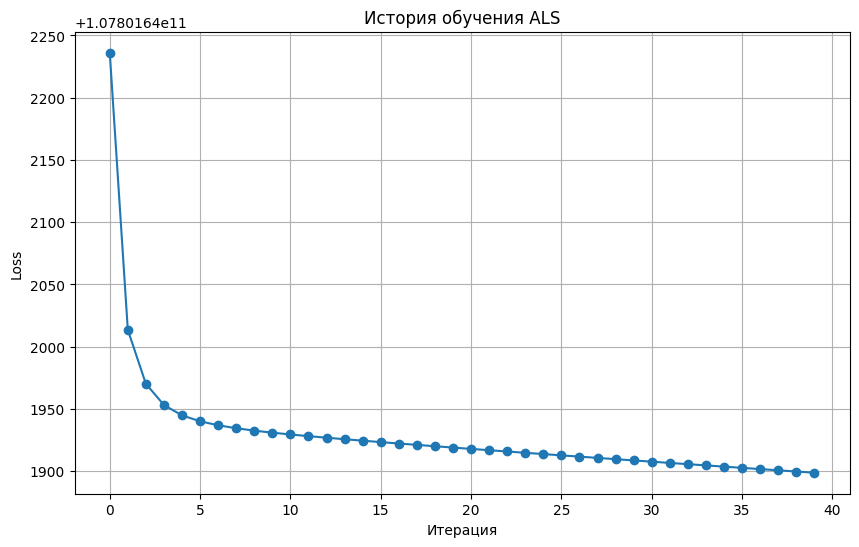


📊 Оценка модели:

✅ Метрики на тестовой выборке:
   RMSE: 93.1656
   MSE:  8679.8244
   MAE:  92.2294

   Оценено пар: 13602
   Пропущено (Cold Start): 0

⏱ Время предсказаний: 0.02 сек
⚡ Скорость: 683220 предсказаний/сек


In [44]:
import numpy as np
from sklearn.metrics import mean_squared_error
import time
from scipy.sparse import coo_matrix

print("\n" + "="*50)
print("🚀 ALS Matrix Factorization")
print("="*50)

# Инициализация модели
als_model = ALS(
    n_factors=25,
    alpha=20,
    regularization=0.01,
    iterations=40
)

# Обучение модели
print("\n📚 Обучение модели...")
start_fit = time.time()
als_model.fit(train_matrix)
fit_time = time.time() - start_fit
print(f"✅ Обучение завершено за {fit_time:.2f} сек")

# Визуализация процесса обучения (если метод существует)
try:
    als_model.plot_loss()
except AttributeError:
    print("⚠️ Метод plot_loss() недоступен")

# Оценка модели
print("\n📊 Оценка модели:")

# ⚡ ОПТИМИЗАЦИЯ: Итерируем только по ненулевым элементам!
# Вместо O(users × items) → O(non_zero_elements)
test_coo = test_matrix.tocoo()  # Конвертируем в COO формат для быстрого доступа

test_predictions = []
test_actual = []
cold_start_users = 0
cold_start_items = 0

start_pred = time.time()

for u, i, rating in zip(test_coo.row, test_coo.col, test_coo.data):
    try:
        pred = als_model.predict(u, i)
        test_predictions.append(pred)
        test_actual.append(rating)
    except Exception:
        # Обработка cold start (пользователь или товар не в train)
        if u >= train_matrix.shape[0]:
            cold_start_users += 1
        if i >= train_matrix.shape[1]:
            cold_start_items += 1

pred_time = time.time() - start_pred

# Вычисляем метрики
if len(test_predictions) > 0:
    mse = mean_squared_error(test_actual, test_predictions)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(np.array(test_actual) - np.array(test_predictions)))
    
    print(f"\n✅ Метрики на тестовой выборке:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MSE:  {mse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"\n   Оценено пар: {len(test_predictions)}")
    print(f"   Пропущено (Cold Start): {cold_start_users + cold_start_items}")
    if cold_start_users > 0:
        print(f"   ⚠️ Холодных пользователей: {cold_start_users}")
    if cold_start_items > 0:
        print(f"   ⚠️ Холодных товаров: {cold_start_items}")
else:
    print("❌ Нет данных для оценки (все пользователи/товары - cold start)")

print(f"\n⏱ Время предсказаний: {pred_time:.2f} сек")
print(f"⚡ Скорость: {len(test_predictions) / pred_time:.0f} предсказаний/сек")

In [49]:
import pickle
import os

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "als_model.pkl")

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(als_model, f)
print(f"✅ Модель сохранена: {MODEL_PATH}")

✅ Модель сохранена: models\als_model.pkl


In [ ]:
def recommendations__original_ids(user_matrix_index, item_recommendations):
    original_item_ids = [index_to_item[idx] for idx in item_recommendations]
    return user_matrix_index, original_item_ids

In [ ]:
recommended = []
for i in range(len(userids_test)):
    recommended_items, scores = als_model.recommend(userids_test[i], n_recommendations=10)
    recommended.append({'item_id_pred': recommended_items})

result = pd.DataFrame(recommended, userids).reset_index()
result

,index,item_id_pred
0,259,"[1, 0, 334, 702, 2216, 733, 325, 712, 1046, 322]"
1,655,"[263, 2, 5, 4, 3, 628, 523, 877, 796, 222]"
2,753,"[819, 620, 367, 227, 890, 1274, 343, 340, 196,..."
3,835,"[381, 758, 108, 1045, 1439, 418, 2000, 500, 12..."
4,960,"[517, 849, 78, 1070, 27, 26, 25, 24, 720, 3418]"
...,...,...
5014,1096841,"[1125, 971, 2178, 47, 988, 95, 418, 712, 546, 42]"
5015,1097296,"[308, 744, 3297, 933, 793, 233, 1908, 858, 490..."
5016,1097444,"[1102, 236, 206, 944, 29, 147, 561, 1908, 2174..."
5017,1097459,"[1125, 399, 1328, 1684, 998, 1771, 2997, 858, ..."


In [ ]:
recom =[]
for i in range(len(result)):
    user, recommend = recommendations__original_ids(userids[i], result['item_id_pred'][i])
    recom.append({'item_id_pred': recommend})

result_pred = pd.DataFrame(recom, userids).reset_index()
result_pred

,index,item_id_pred
0,259,"[4471, 15549, 14530, 6626, 15845, 9070, 10323,..."
1,655,"[11029, 6273, 11899, 15531, 4946, 14703, 14264..."
2,753,"[16442, 13849, 8252, 13788, 1819, 10879, 3190,..."
3,835,"[3384, 13325, 13545, 8350, 11769, 4457, 14159,..."
4,960,"[13262, 3006, 13058, 8386, 8618, 14915, 1527, ..."
...,...,...
5014,1096841,"[13723, 11081, 14421, 4696, 4829, 4495, 4457, ..."
5015,1097296,"[4740, 7424, 1351, 6738, 8581, 3071, 2910, 350..."
5016,1097444,"[2887, 16064, 15221, 8662, 3076, 6155, 3808, 2..."
5017,1097459,"[13723, 9585, 15021, 7019, 5504, 13373, 1225, ..."


In [ ]:
print('als_map_k =', map_k(result_pred['item_id_pred'], data_test_group['item_id'], k=10, u=len(data_test_group)))

als_map_k = 0.001461501848531137
